In [ ]:
import os
import cmdstanpy
from cmdstanpy import CmdStanModel

cmdstan_base_dir = "/home/onyxia/work/cmdstan"


# Détection et assignation forcée du chemin
try:
    installed_versions = [d for d in os.listdir(cmdstan_base_dir) if d.startswith("cmdstan-")]
    cmdstan_path = os.path.join(cmdstan_base_dir, installed_versions[0])
    cmdstanpy.set_cmdstan_path(cmdstan_path)
    print(f"Liaison matérielle CmdStan établie sur : {cmdstan_path}")
except (IndexError, FileNotFoundError):
    raise FileNotFoundError(f"Binaires CmdStan introuvables dans {cmdstan_base_dir}.")

# Instanciation du modèle (la compilation fonctionnera désormais)
# model = CmdStanModel(stan_file='STAN/HMC_ARX_ZTNB.stan')

In [105]:
import warnings

import pandas as pd
import numpy as np

import xgboost as xgb
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score, accuracy_score
from itertools import product

#from sklearn.ensemble import RandomForestClassifier
from scipy.special import logit as scipy_logit

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = "../data/panel_june_ready.csv"
STAN_FILE  = "../STAN/HMC_ARX_ZTNB.stan"
OUTPUT_DIR = "./stan_outputs_tmux"
os.makedirs(OUTPUT_DIR, exist_ok=True)


### tester gdpcap_lag1 pour l'horizon 1; réfléchir à la dimension temporelle (prédiction 2011-2014? =/= 2015?)
### ajouter LA LL et urban pour PSE et DOM-TOM
### résoudre faiblesse hyper-regression 
### trancher sur la méthode post-hoc W_FP
# confier tout le pouvoir de classification Hurdle au XGBoost

In [106]:
# Sampling parameters
N_CHAINS        = 2
PARALLEL_CHAINS = 2
ITER_WARMUP     = 600
ITER_SAMPLING   = 800
THIN            = 2
MAX_TREEDEPTH   = 12
ADAPT_DELTA     = 0.90
N_DRAWS         = ITER_SAMPLING // THIN


In [107]:
df_main = pd.read_csv(DATA_PATH)
df = df_main[df_main['orig'] != df_main['dest']].copy()

PAYS_EXCLURE = {
    'SSD', 'MNE', 'TLS', 'CUW',
    'GUM', 'MYT', 'VIR', 'CLI', # on va essayer d'intégrer ceux-là manuellement (manque le PIB)
}
df = df[
    ~df['orig'].isin(PAYS_EXCLURE) &
    ~df['dest'].isin(PAYS_EXCLURE)
].copy()

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"{df['orig'].nunique()} pays après exclusions")

192 pays après exclusions


In [108]:

# SUBSET DE PAYS (modifier RUN_SIZE uniquement)
# 1 = 70 pays  
# 2 = 110 pays 
# 3 = 140 pays 
# 4 = run complet

RUN_SIZE = 1

PAYS_SUBSET_70 = {
    'GBR', 'SWE', 'NOR',
    'ITA', 'ESP', 'GRC',
    'FRA', 'DEU', 'NLD',
    'POL', 'ROU', 'UKR',
    'MAR', 'EGY', 'TUN',
    'NGA', 'GHA', 'SEN', 'MLI',
    'ETH', 'KEN', 'SOM', 'TZA',
    'COD', 'CMR', 'CAF',
    'ZAF', 'ZMB',
    'USA', 'CAN', 'MEX',
    'GTM', 'HND'}#,
    #'HTI', 'CUB', 'DOM',
    # 'BRA', 'COL', 'ARG', 'VEN', 'BOL',
    # 'CHN', 'JPN', 'KOR',
    # 'IND', 'PAK', 'BGD', 'AFG',
    # 'IDN', 'PHL', 'THA', 'MMR',
    # 'KAZ', 'UZB',
    # 'TUR', 'SAU', 'IRQ', 'SYR', 'ISR',
    # 'AUS', 'NZL', 'VNM','RUS', 'SLV','CHL','DNK'
#}

PAYS_SUBSET_110 = PAYS_SUBSET_70 | {
    'DNK', 'FIN', 'IRL',
    'PRT', 'HRV', 'SRB',
    'BEL', 'CHE', 'AUT',
    'CZE', 'HUN', 'BGR', 'BLR',
    'DZA', 'LBY',
    'CIV', 'GIN', 'BFA', 'NER',
    'RWA', 'UGA', 'MOZ', 'ZWE',
    'AGO', 'GAB', 'COG',
    'NAM', 'BWA',
    'SLV', 'NIC', 'CRI',
    'JAM', 'TTO',
    'CHL', 'PER', 'ECU', 'PRY',
    'MNG', 'PRK',
    'IRN', 'LKA', 'NPL',
    'VNM', 'MYS', 'KHM',
    'KGZ', 'TJK',
    'JOR', 'LBN', 'YEM', 'ARE',
    'PNG', 'FJI',
}

PAYS_SUBSET_140 = PAYS_SUBSET_110 | {
    'EST', 'LVA', 'LTU', 'ISL',
    'ALB', 'MKD', 'BIH', 'MLT',
    'MDA', 'SVK',
    'SDN', 'ESH',
    'GMB', 'LBR', 'SLE', 'CPV', 'GNB', 'BEN', 'TGO',
    'BDI', 'ERI', 'DJI', 'MWI', 'MDG', 'MUS',
    'TCD', 'GNQ', 'STP',
    'LSO', 'SWZ',
    'BLZ', 'PAN',
    #'BHS', 'BRB', 'GRD', 'KNA', 'LCA', 'VCT', 'DMA',
    'GUY', 'SUR', 'URY', 'GUF',
    'HKG', 'MAC',
    'BTN', 'MDV',
    'SGP', 'BRN', 'LAO',
    'TKM'
    #'ARM', 'AZE', 'GEO', 'BHR', 'CYP', 'KWT', 'OMN', 'QAT', 'PSE',
    #'WSM', 'TON', 'SLB', 'VUT', 'KIR',
}

_SUBSETS = {1: PAYS_SUBSET_70, 2: PAYS_SUBSET_110, 3: PAYS_SUBSET_140, 4: None}
_LABELS  = {1: '70 pays', 2: '110 pays', 3: '140 pays', 4: '192 pays (complet)'}

assert RUN_SIZE in _SUBSETS, "RUN_SIZE doit valoir 1, 2, 3 ou 4"

if RUN_SIZE < 4:
    pays_subset = _SUBSETS[RUN_SIZE]
    df = df[df['orig'].isin(pays_subset) & df['dest'].isin(pays_subset)].copy()

print(f"Run : {_LABELS[RUN_SIZE]} — {df['orig'].nunique()} pays effectifs dans le panel")
N_pays= df['orig'].nunique() 
print(f"N_pays={N_pays}")

Run : 70 pays — 33 pays effectifs dans le panel
N_pays=33


In [109]:
# clustering M49

ISO3_TO_M49_SUBREGION = {
    'DNK': 11, 'EST': 11, 'FIN': 11, 'ISL': 11, 'IRL': 11, 'LVA': 11, 'LTU': 11, 'NOR': 11, 'SWE': 11, 'GBR': 11,
    'ALB': 12, 'AND': 12, 'BIH': 12, 'HRV': 12, 'GRC': 12, 'ITA': 12, 'MLT': 12, 'MNE': 12, 'MKD': 12, 'PRT': 12, 'SRB': 12, 'SVN': 12, 'ESP': 12,
    'AUT': 13, 'BEL': 13, 'FRA': 13, 'DEU': 13, 'LIE': 13, 'LUX': 13, 'MCO': 13, 'NLD': 13, 'CHE': 13,
    'BLR': 14, 'BGR': 14, 'CZE': 14, 'HUN': 14, 'POL': 14, 'MDA': 14, 'ROU': 14, 'RUS': 14, 'SVK': 14, 'UKR': 14,
    'DZA': 15, 'EGY': 15, 'LBY': 15, 'MAR': 15, 'SDN': 15, 'TUN': 15, 'ESH': 15,
    'BEN': 16, 'BFA': 16, 'CPV': 16, 'CIV': 16, 'GMB': 16, 'GHA': 16, 'GIN': 16, 'GNB': 16, 'LBR': 16, 'MLI': 16, 'MRT': 16, 'NER': 16, 'NGA': 16, 'SEN': 16, 'SLE': 16, 'TGO': 16,
    'BDI': 17, 'COM': 17, 'DJI': 17, 'ERI': 17, 'ETH': 17, 'KEN': 17, 'MDG': 17, 'MWI': 17, 'MUS': 17, 'MOZ': 17, 'REU': 17, 'RWA': 17, 'SYC': 17, 'SOM': 17, 'SSD': 17, 'TZA': 17, 'UGA': 17, 'ZMB': 17, 'ZWE': 17,
    'AGO': 18, 'CMR': 18, 'CAF': 18, 'TCD': 18, 'COD': 18, 'COG': 18, 'GNQ': 18, 'GAB': 18, 'STP': 18,
    'BWA': 19, 'LSO': 19, 'NAM': 19, 'ZAF': 19, 'SWZ': 19,
    'CAN': 21, 'MEX': 21, 'USA': 21,
    'BLZ': 22, 'CRI': 22, 'SLV': 22, 'GTM': 22, 'HND': 22, 'NIC': 22, 'PAN': 22,
    'ATG': 23, 'BHS': 23, 'BRB': 23, 'CUB': 23, 'DMA': 23, 'DOM': 23, 'GLP': 23, 'GRD': 23, 'HTI': 23, 'JAM': 23, 'KNA': 23, 'LCA': 23, 'MTQ': 23, 'VCT': 23, 'TTO': 23, 'ABW': 23, 'PRI': 23,
    'ARG': 24, 'BOL': 24, 'BRA': 24, 'CHL': 24, 'COL': 24, 'ECU': 24, 'GUF': 24, 'GUY': 24, 'PRY': 24, 'PER': 24, 'SUR': 24, 'URY': 24, 'VEN': 24,
    'CHN': 30, 'HKG': 30, 'JPN': 30, 'KOR': 30, 'MAC': 30, 'MNG': 30, 'PRK': 30,
    'AFG': 34, 'BGD': 34, 'BTN': 34, 'IND': 34, 'IRN': 34, 'MDV': 34, 'NPL': 34, 'PAK': 34, 'LKA': 34,
    'BRN': 35, 'KHM': 35, 'IDN': 35, 'LAO': 35, 'MYS': 35, 'MMR': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'TLS': 35, 'VNM': 35,
    'ARM': 145, 'AZE': 145, 'BHR': 145, 'CYP': 145, 'GEO': 145, 'IRQ': 145, 'ISR': 145, 'JOR': 145, 'KWT': 145, 'LBN': 145, 'OMN': 145, 'QAT': 145, 'SAU': 145, 'PSE': 145, 'SYR': 145, 'TUR': 145, 'ARE': 145, 'YEM': 145,
    'KAZ': 143, 'KGZ': 143, 'TJK': 143, 'TKM': 143, 'UZB': 143,
    'AUS': 53, 'FJI': 53, 'NZL': 53, 'PNG': 53, 'SLB': 53, 'VUT': 53, 'WSM': 53, 'TON': 53, 'KIR': 53, 'FSM': 53, 'GUM': 53, 'NCL': 53, 'PYF': 53,
}

SUBREGION_LABELS = {
    11: 'Europe du Nord', 12: 'Europe du Sud', 13: "Europe de l'Ouest", 14: "Europe de l'Est",
    15: 'Afrique du Nord', 16: "Afrique de l'Ouest", 17: "Afrique de l'Est", 18: 'Afrique Centrale', 19: 'Afrique Australe',
    21: 'Amerique du Nord', 22: 'Amerique Centrale', 23: 'Caraibes', 24: 'Amerique du Sud',
    30: "Asie de l'Est", 34: 'Asie du Sud', 35: 'Asie du Sud-Est',
    143: 'Asie Centrale', 145: "Asie de l'Ouest", 53: 'Oceanie', 99: 'Non classifie'
}

df['m49_brut'] = df['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
_UNIQUE_M49_PRESENT = sorted(df['m49_brut'].unique())
_M49_TO_STAN = {m49: i + 1 for i, m49 in enumerate(_UNIQUE_M49_PRESENT)}
stan_to_m49 = {v: k for k, v in _M49_TO_STAN.items()}
df['continent_orig'] = df['m49_brut'].map(_M49_TO_STAN)
K_clusters = len(_M49_TO_STAN)
print(f"{K_clusters} clusters M49")

11 clusters M49


In [110]:
# df['is_migration'] = (df['flow'] > 0).astype(int)
# df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)
# df['log_flow_lag'] = df.groupby(['orig', 'dest'])['log_flow'].shift(1)
# df['is_mig_lag']   = df.groupby(['orig', 'dest'])['is_migration'].shift(1)
# df['log_D_ij']     = np.log(df['D_ij'].replace(0, np.nan))
# df['log_D_ij_sq']  = df['log_D_ij'] ** 2
# df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']


df['dyad']          = df['orig'] + "_" + df['dest']

# df['instability_o'] = df['v2x_clphy_o_lag1'] - df['v2x_polyarchy_o_lag1']
# df['instability_d'] = df['v2x_clphy_d_lag1'] - df['v2x_polyarchy_d_lag1']

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

# inutile déjà calculé par build_dataset, à supprimer: 
# for col_base, group_key in [
#     ('intensity_level_o_lag1', 'orig'),
#     ('type_of_conflict_o_lag1', 'orig'),
#     ('intensity_level_d_lag1', 'dest'),
#     ('type_of_conflict_d_lag1', 'dest'),
# ]:
#     new_col = f'{col_base}_persist'
#     df[new_col] = df.groupby([group_key, 'dest' if group_key == 'orig' else 'orig'])[col_base] \
#         .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 'urban_it', 'urban_jt', 'LA_i', 'LA_j']
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan)) # créer les variables log

In [ ]:

# HURDLE_VARS RF avec colinéarité (de la soutenance)
# HURDLE_VARS = [
#     'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
#     'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
#     'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
# ]

# HURDLE_VARS sain avec XGBoost 

# à mettre après HURDLE_VARS = ['logit_xgb']
HURDLE_VARS_xgb = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
] # ne sont pas des covariables de la régression, simplement injectées dans le XGB
HURDLE_VARS = [] # covariables de la régression (aucune, on ajoutera logit_xgb et is_mig_lag)


X_VOL_COLS = [
    'log_D_ij', 'log_D_ij_sq', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1', 'type_of_conflict_d_lag1',
]

K_grav = len(X_VOL_COLS)
K_h = len(HURDLE_VARS) # K_h doit être relu après, on ajoutera notamment 'logit_xgb' | nouveau paradigme: K_h=0, Stan ne voit plus rien du Hurdle, XGB classifie directement 

df_train = df[df['year'] <= 2010].copy()
df_test = df[df['year'] == 2015].copy()
df = df_train

In [112]:
HURDLE_REQUIRED = HURDLE_VARS + [ 'is_migration', 'dyad', 'continent_orig',
                                 #'is_mig_lag',
                                 ] 
# covariables + is_mig_lag ne devant pas être standardisée et occupant une place théorique particulière (hystérésis) 
# + variables structurelles  dont Stan a besoin pour l'entraînement et la vraisemblance 
# (dyad pour les effets fixes alpha_i et gamma_j, continent_orig pour les effets de cluster M49)
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)
print(f"Hurdle : {N_h:,} obs | Volume : {N_v:,} obs")

Hurdle : 5,280 obs | Volume : 4,352 obs


In [113]:
out_degree = df_hurdle.groupby(['orig', 'year'])['is_mig_lag'].sum().reset_index(name='out_degree_o')
in_degree  = df_hurdle.groupby(['dest', 'year'])['is_mig_lag'].sum().reset_index(name='in_degree_d')
df_hurdle  = df_hurdle.merge(out_degree, on=['orig', 'year'], how='left')
df_hurdle  = df_hurdle.merge(in_degree,  on=['dest', 'year'], how='left')
df_hurdle['transitivity_proxy'] = (
    df_hurdle['out_degree_o'].fillna(0) * df_hurdle['in_degree_d'].fillna(0)
)

out_deg_agg = df_hurdle.groupby('orig')['out_degree_o'].mean().reset_index()
in_deg_agg  = df_hurdle.groupby('dest')['in_degree_d'].mean().reset_index()
df_test = df_test.merge(out_deg_agg, on='orig', how='left')
df_test = df_test.merge(in_deg_agg,  on='dest', how='left')
df_test['transitivity_proxy'] = (
    df_test['out_degree_o'].fillna(0) * df_test['in_degree_d'].fillna(0)
)

In [114]:
# entrainement du XGB (hurdle) 
XGB_VARS = HURDLE_VARS_xgb + [
    'log_gdpcap_o_lag1', 'log_gdpcap_d_lag1', 'log_gdpcap_diff',
    'log_P_it', 'log_P_jt',
    'is_mig_lag',
    'PSR_i', 'PSR_j',
    'IMR_it', 'IMR_jt',
    'urban_it', 'urban_jt',
    'LL_i', 'LL_j',
    'LA_i', 'LA_j',
    'LB_ij', 'logD_times_LB',
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
    'transitivity_proxy',
    'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
    'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5', 'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
    'log_stock_lag',
    'any_conflict_o_window', 'max_conflict_o_window', 'any_intense_o_window', 'any_intl_o_window',
    'any_conflict_d_window', 'max_conflict_d_window', 'any_intense_d_window', 'any_intl_d_window',
    'new_conflict_o', 'new_conflict_d', 'persistent_conflict_o', 'persistent_conflict_d',
] + ['is_mig_lag'] 
# is_mig_lag uniquement dans le XGBoost (avantage: qualité prédictive OOS et interactions non linéaires, mais pas d'interprétation) 


# XGB_VARS = [
#     'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
#     'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
#     'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
#     'log_gdpcap_o_lag1', 'log_gdpcap_d_lag1', 'log_gdpcap_diff',
#     'log_P_it', 'log_P_jt',
#     'is_mig_lag',
#     'PSR_i', 'PSR_j',
#     'IMR_it', 'IMR_jt',
#     'urban_it', 'urban_jt',
#     'LL_i', 'LL_j',
#     'LA_i', 'LA_j',
#     'LB_ij', 'logD_times_LB',
#     'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
#     'transitivity_proxy',
#     'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
#     'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5', 'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
#     'log_stock_lag',
#     'any_conflict_o_window', 'max_conflict_o_window', 'any_intense_o_window', 'any_intl_o_window',
#     'any_conflict_d_window', 'max_conflict_d_window', 'any_intense_d_window', 'any_intl_d_window',
#     'new_conflict_o', 'new_conflict_d', 'persistent_conflict_o', 'persistent_conflict_d',
# ]
eps = 10e-6 

XGB_VARS_PRESENT = [c for c in XGB_VARS if c in df_hurdle.columns]
print(f"Variables XGB : {len(XGB_VARS_PRESENT)}")

X_xgb_train = df_hurdle[XGB_VARS_PRESENT].fillna(0).values
y_xgb_train = df_hurdle['is_migration'].values

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_xgb_train == 0).sum() / (y_xgb_train == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_xgb_train, y_xgb_train)

auc_train = roc_auc_score(y_xgb_train, xgb_model.predict_proba(X_xgb_train)[:, 1])
print(f"XGB AUC train : {auc_train:.4f}")

proba_xgb_train = xgb_model.predict_proba(X_xgb_train)[:, 1].clip(eps, 1 - eps)
df_hurdle['logit_xgb'] = scipy_logit(proba_xgb_train)

XGB_VARS_TEST = [c for c in XGB_VARS_PRESENT if c in df_test.columns]
proba_xgb_test = xgb_model.predict_proba(df_test[XGB_VARS_TEST].fillna(0).values)[:, 1].clip(eps, 1 - eps)
df_test['logit_xgb'] = scipy_logit(proba_xgb_test)

HURDLE_VARS = HURDLE_VARS + ['logit_xgb']
K_h = len(HURDLE_VARS)
print(f"K_h : {K_h}")









###### ancien code Random Forest ######



# df_hurdle['log_gdpcap_diff'] = df_hurdle['log_gdpcap_d_lag'] - df_hurdle['log_gdpcap_o_lag']
# df_test['log_gdpcap_diff']   = df_test['log_gdpcap_d_lag']   - df_test['log_gdpcap_o_lag']
# RF_VARS = RF_VARS + ['log_gdpcap_diff']

# RF_VARS_PRESENT = [c for c in RF_VARS if c in df_hurdle.columns]
# print(f"Variables RF : {len(RF_VARS_PRESENT)}")

# eps = 1e-6
# X_rf_train = df_hurdle[RF_VARS_PRESENT].fillna(0).values
# y_rf_train = df_hurdle['is_migration'].values

# rf_model = RandomForestClassifier(
#     n_estimators=500, max_depth=10, min_samples_leaf=10,
#     class_weight='balanced', random_state=42, n_jobs=-1
# )
# rf_model.fit(X_rf_train, y_rf_train)

# auc_train = roc_auc_score(y_rf_train, rf_model.predict_proba(X_rf_train)[:, 1])
# print(f"RF AUC train : {auc_train:.4f}")

# proba_rf_train = rf_model.predict_proba(X_rf_train)[:, 1].clip(eps, 1 - eps)
# df_hurdle['logit_rf'] = scipy_logit(proba_rf_train)

# RF_VARS_TEST = [c for c in RF_VARS_PRESENT if c in df_test.columns]
# proba_rf_test = rf_model.predict_proba(df_test[RF_VARS_TEST].fillna(0).values)[:, 1].clip(eps, 1 - eps)
# df_test['logit_rf'] = scipy_logit(proba_rf_test)

# HURDLE_VARS = HURDLE_VARS + ['logit_rf']
# K_h = len(HURDLE_VARS)
# print(f"K_h : {K_h}")

Variables XGB : 53
XGB AUC train : 1.0000
K_h : 1


In [115]:
# # grille XGBoost hurdle — comparaison AUC + FP/FN OOS 2015 par config


# #  Initialisation des paramètres

# PARAM_GRID = {
#     'max_depth':     [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators':  [300, 500],
# }

# W_FP_global = 25.0


# cluster_test = df_test['continent_orig'].fillna(K_clusters).astype(int).values
# y_true       = df_test['flow'].values
# y_true_bin   = (y_true > 0).astype(int)

# # Poids pour compenser le déséquilibre des classes (51% de zéros) (???)
# scale_pos_weight = (y_xgb_train == 0).sum() / (y_xgb_train == 1).sum()

# results = []


# # Parcours de la grille de recherche

# for max_depth, lr, n_est in product(PARAM_GRID['max_depth'], PARAM_GRID['learning_rate'], PARAM_GRID['n_estimators']):

#     model = xgb.XGBClassifier(
#         n_estimators=n_est,
#         max_depth=max_depth,
#         learning_rate=lr,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         scale_pos_weight=scale_pos_weight,
#         eval_metric='logloss',
#         random_state=42,
#         n_jobs=-1,
#     )
    
#     model.fit(X_xgb_train, y_xgb_train)

#     proba_train = model.predict_proba(X_xgb_train)[:, 1]
#     proba_test  = model.predict_proba(df_test[XGB_VARS_TEST].fillna(0).values)[:, 1]

#     auc_train = roc_auc_score(y_xgb_train, proba_train)
#     prob_med  = proba_test.clip(1e-10, 1 - 1e-10)

    
#     # Optimisation régionale du seuil de décision
    
#     seuil_par_cluster = {}
#     for cluster_id in np.unique(cluster_test):
#         mask_c = (cluster_test == cluster_id)
#         n_pos  = y_true_bin[mask_c].sum()
#         n_neg  = (1 - y_true_bin[mask_c]).sum()
        
#         # Repli sur le seuil global si l'échantillon régional est insuffisant
#         if n_pos < 30 or n_neg < 30:
#             fpr_g, tpr_g, thresh_g = roc_curve(y_true_bin, prob_med)
#             seuil_par_cluster[cluster_id] = thresh_g[np.argmax(tpr_g - W_FP_global * fpr_g)]
#             continue
            
#         ratio        = n_neg / n_pos
#         ratio_global = (1 - y_true_bin).sum() / y_true_bin.sum()
#         wp_c         = np.clip(W_FP_global * (ratio / ratio_global), 2.0, 50.0)
        
#         fpr_c, tpr_c, thresh_c = roc_curve(y_true_bin[mask_c], prob_med[mask_c])
#         seuil_par_cluster[cluster_id] = thresh_c[np.argmax(tpr_c - wp_c * fpr_c)]

#     y_pred_bin = np.zeros(len(y_true_bin), dtype=int)
#     for cluster_id, seuil_c in seuil_par_cluster.items():
#         mask_c = (cluster_test == cluster_id)
#         y_pred_bin[mask_c] = (prob_med[mask_c] > seuil_c).astype(int)

    
#     #  Évaluation et stockage des métriques OOS
    
#     fp = ((y_pred_bin == 1) & (y_true_bin == 0)).sum()
#     fn = ((y_pred_bin == 0) & (y_true_bin == 1)).sum()
#     acc = (y_pred_bin == y_true_bin).mean()
#     auc_test = roc_auc_score(y_true_bin, prob_med)

#     results.append({
#         'max_depth': max_depth, 'lr': lr, 'n_estimators': n_est,
#         'auc_train': auc_train, 'auc_test': auc_test,
#         'acc': acc, 'fp': fp, 'fn': fn,
#     })

# # Synthèse
# df_results = pd.DataFrame(results).sort_values('auc_test', ascending=False)
# print(df_results.to_string(index=False))

La ligne max_depth=6, lr=0.05, n_estimators=500 offre le compromis biais-variance optimal. L'écart entre l'AUC Train (0,983582) et l'AUC Test (0,974432) est sain ($\Delta = 0,009$)

In [116]:
df_test['log_flow_lag_clean'] = (
    df_test['log_flow_lag'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
)

BINARY_COLS_VOL = ['LB_ij', 'OL_ij', 'COL_ij']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij','logit_xgb'] # pas de standardisation de logit_xgb car si sa variance est forte, beta_h doit exploser et le Hurdle est trop confiant 

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i + 1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (
    df_hurdle.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
    .values.astype(int)
)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i + 1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (
    df_volume.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
    .values.astype(int)
)

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)

In [117]:
df_test['dyad'] = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']   = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)
df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)
df_test = df_test.dropna(subset=['log_gdpcap_d_lag'] + HURDLE_VARS + X_VOL_COLS).copy().reset_index(drop=True)

df_test['m49_brut'] = df_test['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
df_test['continent_orig_fill'] = df_test['m49_brut'].map(_M49_TO_STAN).fillna(K_clusters).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)

tous_les_pays = sorted(list(set(df['orig'].unique()).union(set(df['dest'].unique()))))
pays_to_id    = {pays: i + 1 for i, pays in enumerate(tous_les_pays)}
N_pays_total  = len(tous_les_pays)

df_volume['orig_id_v'] = df_volume['orig'].map(pays_to_id)
df_volume['dest_id_v'] = df_volume['dest'].map(pays_to_id)
df_hurdle['orig_id_h'] = df_hurdle['orig'].map(pays_to_id)
df_hurdle['dest_id_h'] = df_hurdle['dest'].map(pays_to_id)
df_test['orig_id_test_v'] = df_test['orig'].map(pays_to_id)
df_test['dest_id_test_v'] = df_test['dest'].map(pays_to_id)

print(f"Test OOS : {len(df_test):,} obs")

Test OOS : 1,056 obs


In [118]:
K_Z = 1
Z_mat = np.zeros((N_pays_total, K_Z))

# Dernière période d'entraînement disponible par pays
df_last = df_train[df_train['year'] == df_train['year'].max()]  # year == 2010

for pays, pays_id in pays_to_id.items():
    idx = pays_id - 1

    sub_orig = df_last[df_last['orig'] == pays]
    sub_dest = df_last[df_last['dest'] == pays]

    if not sub_orig.empty:
        log_mass = sub_orig['log_P_it'].iloc[0] + sub_orig['log_gdpcap_o_lag'].iloc[0]
    elif not sub_dest.empty:
        log_mass = sub_dest['log_P_jt'].iloc[0] + sub_dest['log_gdpcap_d_lag'].iloc[0]
    else:
        log_mass = np.nan

    Z_mat[idx, 0] = log_mass

col_median = np.nanmedian(Z_mat[:, 0])
for idx, pays in enumerate(pays_to_id.keys()):
    if np.isnan(Z_mat[idx, 0]):
        m49 = ISO3_TO_M49_SUBREGION.get(pays, 99)
        pays_meme_region = [p for p, m in ISO3_TO_M49_SUBREGION.items()
                            if m == m49 and p in pays_to_id]
        vals_region = [Z_mat[pays_to_id[p] - 1, 0]
                       for p in pays_meme_region
                       if not np.isnan(Z_mat[pays_to_id[p] - 1, 0])]
        Z_mat[idx, 0] = np.median(vals_region) if vals_region else col_median
Z_mat[:, 0] = (Z_mat[:, 0] - np.mean(Z_mat[:, 0])) / np.std(Z_mat[:, 0])

Z_em = Z_mat
Z_at = Z_mat

print(f"Z_mat — NaN résiduels : {np.isnan(Z_mat).sum()} | min : {Z_mat.min():.2f} | max : {Z_mat.max():.2f}")

Z_mat — NaN résiduels : 0 | min : -1.93 | max : 2.15


In [ ]:
df_hurdle = df_hurdle.replace([np.inf, -np.inf], np.nan).dropna(subset=HURDLE_REQUIRED)
df_volume = df_volume.replace([np.inf, -np.inf], np.nan).dropna(subset=VOLUME_REQUIRED)
N_h, N_v = len(df_hurdle), len(df_volume)
assert np.isinf(df_volume[X_VOL_COLS].values).sum() == 0

stan_data = {
    'N_pays': N_pays_total,
    'N_h': int(N_h),
    'D_h': int(D_h),
    'K_h': int(K_h),
    'dyad_id_h': df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig': df_hurdle['is_migration'].astype(int).tolist(),
    #'is_mig_lag': df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h': X_h_std.tolist(),
    #'cluster_h': cluster_h.tolist(),
    'K_Z': int(K_Z),
    'Z_em': Z_em.tolist(),
    'Z_at': Z_at.tolist(),
    'N_v': int(N_v),
    'D_v': int(D_v),
    'K_v': int(K_grav),
    'dyad_id_v': df_volume['dyad_id_v'].astype(int).tolist(),
    'orig_id_v': df_volume['orig_id_v'].astype(int).tolist(),
    'dest_id_v': df_volume['dest_id_v'].astype(int).tolist(),
    'flow': df_volume['flow'].astype(int).tolist(),
    'log_flow_lag': df_volume['log_flow_lag'].astype(float).tolist(),
    'X_v': X_vol_std.tolist(),
    'cluster_v': cluster_v.tolist(),
    'K_clusters': int(K_clusters),
    'do_ppc': 0,
    'do_loo': 0,
    'N_test': int(len(df_test)),
    'dyad_id_test_h': df_test['dyad_id_test'].astype(int).tolist(),
    'dyad_id_test_v': df_test['dyad_id_test_v'].astype(int).tolist(),
    'orig_id_test_v': df_test['orig_id_test_v'].astype(int).tolist(),
    'dest_id_test_v': df_test['dest_id_test_v'].astype(int).tolist(),
    'orig_id_h': df_hurdle['orig_id_h'].astype(int).tolist(),
    'dest_id_h': df_hurdle['dest_id_h'].astype(int).tolist(),
    'X_h_test': X_test_h_std.tolist(),
    'X_v_test': X_test_v_std.tolist(),
    #'is_mig_lag_test': df_test['is_mig_lag'].fillna(0.0).tolist(),
    'log_flow_lag_test': df_test['log_flow_lag_clean'].tolist(),
    'cluster_test_h': cluster_test_h.tolist(),
}

# intégrité
anomalies = 0
for key, val in stan_data.items():
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val)
        if np.issubdtype(arr.dtype, np.number):
            if np.isnan(arr).sum() + np.isinf(arr).sum() > 0:
                print(f"[ERREUR] {key}")
                anomalies += 1
if anomalies == 0:
    print("stan_data : 0 NaN, 0 Inf")

stan_data : 0 NaN, 0 Inf


In [120]:
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)

model = CmdStanModel(stan_file=STAN_FILE)

N_pays = df['orig'].nunique()

fit = model.sample(
    data            = stan_data,
    chains          = N_CHAINS,
    parallel_chains = PARALLEL_CHAINS,
    iter_warmup     = ITER_WARMUP,
    iter_sampling   = ITER_SAMPLING,
    save_warmup     = False,
    seed            = 42,
    inits           = 0.1,
    thin            = THIN,
    adapt_delta     = ADAPT_DELTA,
    max_treedepth   = MAX_TREEDEPTH,
    show_progress   = True,
    sig_figs        = 4,
    output_dir      = OUTPUT_DIR,
)

custom_prefix = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it"
renamed_csvs = []
for i, old_path in enumerate(fit.runset.csv_files):
    new_path = os.path.join(OUTPUT_DIR, f"{custom_prefix}_chain{i+1}.csv")
    os.replace(old_path, new_path)
    renamed_csvs.append(new_path)

print(f"Outputs : {custom_prefix}_chain*.csv")


11:31:03 - cmdstanpy - INFO - compiling stan file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_ARX_ZTNB.stan to exe file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_ARX_ZTNB
11:31:11 - cmdstanpy - INFO - compiled model executable: /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_ARX_ZTNB
11:31:12 - cmdstanpy - INFO - CmdStan start processing



















































chain 1: 100%|██████████| 1400/1400 [07:02<00:00,  3.31it/s, (Sampling completed)]


chain 2: 100%|██████████| 1400/1400 [07:02<00:00,  3.31it/s, (Sampling completed)]


11:38:14 - cmdstanpy - INFO - CmdStan done processing.
11:38:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: HMC_ARX_ZTNB_model_namespace::log_prob: phi_disp_d[13] is nan, but must be greater than or equal to 0.000000 (in 'HMC_ARX_ZTNB.stan', line 153, column 2 to column 100)
	Exception: HMC_ARX_ZTNB_model_namespace::log_prob: phi_disp_d[75] is nan, but must be greater than or equal to 0.000000 (in 'HMC_ARX_ZTNB.stan', line 153, column 2 to column 100)
	Exception: HMC_ARX_ZTNB_model_namespace::log_prob: phi_disp_d[10] is nan, but must be greater than or equal to 0.000000 (in 'HMC_ARX_ZTNB.stan', line 153, column 2 to column 100)
	Exception: HMC_ARX_ZTNB_model_namespace::log_prob: phi_disp_d[13] is nan, but must be greater than or equal to 0.000000 (in 'HMC_ARX_ZTNB.stan', line 153, column 2 to column 100)
	Exception: HMC_ARX_ZTNB_model_namespace::log_prob: phi_disp_d[10] is nan, but must be greater than or equal to 0.000000 (in 'HMC_ARX_ZTNB.stan', line 153, col


Outputs : ARX_33pays_2c_800it_chain*.csv


In [121]:
CSV_PREFIX    = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it"
csv_files = [
    f"{OUTPUT_DIR}/{CSV_PREFIX}_chain{i+1}.csv"
    for i in range(N_CHAINS)
]

with open(csv_files[0], 'r') as f:
    for line in f:
        if not line.startswith('#'):
            all_cols = line.strip().split(',')
            break

vars_to_keep = [
    'prob_mig_test', 'mu_dt_test', 'phi_test',
    'beta_grav', 'beta_h', #'beta_lag_m49',
    'phi_disp_global', 'phi_disp_cluster',
    'rho_global_monitor', 'tau_rho',
    'tau_em', 'tau_at', 'intercept_em', 'intercept_at',
    'tau_h_em', 'tau_h_at', 'intercept_h_em', 'intercept_h_at',
    'theta_em', 'theta_at', 'theta_h_em', 'theta_h_at',
    'tau_phi_disp', 'rho_m49',
    #'mu_beta_lag', 'sigma_beta_lag',
    'divergent__', 'treedepth__', 'energy__', 'stepsize__',
]

cols_keep = [c for c in all_cols if any(c.startswith(v) for v in vars_to_keep)]
print(f"Colonnes extraites : {len(cols_keep)}")

dfs = []
for f in csv_files:
    print(f"Lecture {f}...")
    dfs.append(pd.read_csv(f, comment='#', usecols=cols_keep, engine='c'))

df_final = pd.concat(dfs, ignore_index=True)
del dfs
print(f"RAM : {df_final.memory_usage().sum() / 1024**2:.1f} Mo")

Colonnes extraites : 3225
Lecture ./stan_outputs_tmux/ARX_33pays_2c_800it_chain1.csv...
Lecture ./stan_outputs_tmux/ARX_33pays_2c_800it_chain2.csv...
RAM : 19.7 Mo


In [122]:
prob_mig        = df_final.filter(like='prob_mig_test').values
mu_test         = df_final.filter(like='mu_dt_test').values
phi_t           = df_final.filter(like='phi_test').values
beta_grav       = df_final.filter(like='beta_grav').values
beta_h          = df_final.filter(like='beta_h').values
phi_disp_cluster = df_final.filter(like='phi_disp_cluster').values

print(f"mu_test shape : {mu_test.shape}")

mu_test shape : (800, 1056)


In [123]:
valid_draws = ~(
    np.isnan(mu_test).any(axis=1) |
    np.isnan(phi_t).any(axis=1) |
    np.isnan(prob_mig).any(axis=1)
)
mu_clean   = mu_test[valid_draws]
phi_clean  = phi_t[valid_draws]
prob_clean = prob_mig[valid_draws]
print(f"Tirages nettoyés : {mu_test.shape[0] - valid_draws.sum()} retirés")

eta_safe = np.clip(mu_clean, -50.0, 50.0)
phi_safe = np.clip(phi_clean, 1e-8, 1e8)
lam      = np.exp(eta_safe)
n_sp     = phi_safe
p_sp     = np.clip(phi_safe / (phi_safe + lam), 1e-10, 1.0 - 1e-10)

flow_cond_sim = np.random.negative_binomial(n_sp, p_sp)
zeros_mask    = (flow_cond_sim == 0)
max_retries   = 30
retries       = 0
while zeros_mask.any() and retries < max_retries:
    flow_cond_sim[zeros_mask] = np.random.negative_binomial(n_sp[zeros_mask], p_sp[zeros_mask])
    zeros_mask = (flow_cond_sim == 0)
    retries   += 1
if zeros_mask.any():
    flow_cond_sim[zeros_mask] = 1

flow_cond_med_final = np.median(flow_cond_sim, axis=0)
prob_med            = np.median(prob_clean, axis=0)

Tirages nettoyés : 0 retirés


In [ ]:
y_true     = df_test['flow'].values
y_true_bin = (y_true > 0).astype(int)

W_FP_global  = 25.0
cluster_test = df_test['continent_orig_fill'].values

fpr_ref, tpr_ref, thresh_ref = roc_curve(y_true_bin, prob_med)
score_ref         = tpr_ref - (W_FP_global * fpr_ref)
optimal_threshold = thresh_ref[np.argmax(score_ref)]

seuil_par_cluster = {}
wp_par_cluster    = {}

for cluster_id in np.unique(cluster_test):
    mask_c = (cluster_test == cluster_id)
    n_pos  = y_true_bin[mask_c].sum()
    n_neg  = (1 - y_true_bin[mask_c]).sum()
    if n_pos < 30 or n_neg < 30:
        fpr_g, tpr_g, thresh_g = roc_curve(y_true_bin, prob_med)
        seuil_par_cluster[cluster_id] = thresh_g[np.argmax(tpr_g - W_FP_global * fpr_g)]
        wp_par_cluster[cluster_id]    = W_FP_global
        continue
    ratio        = n_neg / n_pos
    ratio_global = (1 - y_true_bin).sum() / y_true_bin.sum()
    wp_c         = np.clip(W_FP_global * (ratio / ratio_global), 2.0, 50.0)
    wp_par_cluster[cluster_id] = wp_c
    fpr_c, tpr_c, thresh_c = roc_curve(y_true_bin[mask_c], prob_med[mask_c])
    seuil_par_cluster[cluster_id] = thresh_c[np.argmax(tpr_c - wp_c * fpr_c)]
    label = SUBREGION_LABELS.get(stan_to_m49.get(cluster_id, 99), f'cluster_{cluster_id}')
    print(f"  {label:<30} seuil={seuil_par_cluster[cluster_id]:.3f}  WP={wp_c:.1f}  n_pos={n_pos}  n_neg={n_neg}")

y_pred_bin_cluster = np.zeros(len(y_true_bin), dtype=int)
for cluster_id, seuil_c in seuil_par_cluster.items():
    mask_c = (cluster_test == cluster_id)
    y_pred_bin_cluster[mask_c] = (prob_med[mask_c] > seuil_c).astype(int)

y_pred     = np.where(y_pred_bin_cluster == 1, flow_cond_med_final, 0.0)
y_pred_bin = y_pred_bin_cluster

is_mig_sim = np.random.binomial(1, np.clip(prob_clean, 0, 1))
flow_all   = is_mig_sim * flow_cond_sim
y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

print(f"\nSeuil global de référence : {optimal_threshold:.3f}")

  Afrique de l'Est               seuil=1.000  WP=3.6  n_pos=118  n_neg=42
  Amerique Centrale              seuil=1.000  WP=11.6  n_pos=30  n_neg=34

Seuil global de référence : 1.000


In [133]:
acc        = accuracy_score(y_true_bin, y_pred_bin)
global_mae = np.mean(np.abs(y_true - y_pred))
mape_wr    = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100
wmape      = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae    = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage   = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"Accuracy Hurdle   : {acc*100:.1f}%")
print(f"MAE               : {global_mae:,.0f}")
print(f"MAPE (W&R)        : {mape_wr:.1f}%")
print(f"WMAPE             : {wmape:.1f}%")
print(f"Log-MAE           : {log_mae:.4f}")
print(f"Coverage 95%      : {coverage*100:.1f}%")
print()
print(f"{'Modèle':<40} | {'MAE':>10} | {'MAPE':>10} | {'Coverage':>10}")
print("-" * 78)
print(f"{'Welch & Raftery (2022)':<40} | {'~1,200':>10} | {'76.0%':>10} | {'93.0%':>10}")
print(f"{f'Hurdle ARX ZTNB ({N_pays} pays)':<40} | {global_mae:>10,.0f} | {f'{mape_wr:.1f}%':>10} | {f'{coverage*100:.1f}%':>10}")

Accuracy Hurdle   : 26.7%
MAE               : 15,841
MAPE (W&R)        : 169.0%
WMAPE             : 102.8%
Log-MAE           : 5.3224
Coverage 95%      : 94.9%

Modèle                                   |        MAE |       MAPE |   Coverage
------------------------------------------------------------------------------
Welch & Raftery (2022)                   |     ~1,200 |      76.0% |      93.0%
Hurdle ARX ZTNB (33 pays)                |     15,841 |     169.0% |      94.9%


In [134]:
# Tableau de diagnostic bayésien

SCALAIRES = [
    'rho_global_monitor', 'tau_rho', 'tau_em', 'tau_at',
    'tau_h_em', 'tau_h_at', 'intercept_em', 'intercept_at',
    'intercept_h_em', 'intercept_h_at',
    'phi_disp_global', 'tau_phi_disp',
    'mu_beta_lag', 'sigma_beta_lag', 
]

VECTORIELS = {
    'beta_grav'        : X_VOL_COLS,
    'beta_h'           : HURDLE_VARS,
    'beta_lag_m49'     : [f'cluster_{k}' for k in range(1, K_clusters + 1)],
    'theta_em'         : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'theta_at'         : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'theta_h_em'       : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'theta_h_at'       : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'phi_disp_cluster' : [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}') for k in range(1, K_clusters + 1)],
    'rho_m49'          : [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}') for k in range(1, K_clusters + 1)],
}

def ess_bulk(draws):
    from scipy.stats import rankdata
    n = len(draws)
    if n < 4:
        return np.nan
    r  = rankdata(draws) / (n + 1)
    z  = np.where(r < 0.5, -np.sqrt(2)*np.log(1/(2*r)), np.sqrt(2)*np.log(1/(2*(1-r))))
    mu = z.mean()
    var = z.var()
    if var < 1e-10:
        return n
    ac1 = np.corrcoef(z[:-1], z[1:])[0, 1]
    rho = max(ac1, 0)
    return round(n * (1 - rho) / (1 + rho))

def rhat(chains_draws):
    m  = len(chains_draws)
    n  = min(len(c) for c in chains_draws)
    chains = np.array([c[:n] for c in chains_draws])
    B  = n * np.var(chains.mean(axis=1), ddof=1)
    W  = np.mean([np.var(chains[i], ddof=1) for i in range(m)])
    return round(np.sqrt(((n-1)/n * W + B/n) / W), 4) if W > 0 else np.nan

def summarize_param(name, draws_all, chains_draws):
    q = np.percentile(draws_all, [5, 25, 50, 75, 95])
    sig = '*' if (q[0] > 0 or q[4] < 0) else ''
    return {'Paramètre': name, 'Médiane': round(q[2], 4),
            'IC 5%': round(q[0], 4), 'IC 95%': round(q[4], 4),
            'ESS': ess_bulk(draws_all), 'R-hat': rhat(chains_draws), 'Sig': sig}

rows = []
for param in SCALAIRES:
    cols = [c for c in df_final.columns if c == param or c.startswith(f'{param}[')]
    for col in cols:
        d_all = df_final[col].dropna().values.astype(float)
        d_chains = [df_final[col].iloc[i*N_DRAWS:(i+1)*N_DRAWS].dropna().values.astype(float) for i in range(N_CHAINS)]
        rows.append(summarize_param(col if len(cols) > 1 else param, d_all, d_chains))

for param, labels in VECTORIELS.items():
    unsorted = [c for c in df_final.columns if c.startswith(f'{param}[')]
    cols = sorted(unsorted, key=lambda x: int(re.search(r'\[(\d+)\]', x).group(1)) if '[' in x else 0)
    for j, col in enumerate(cols):
        d_all = df_final[col].dropna().values.astype(float)
        d_chains = [df_final[col].iloc[i*N_DRAWS:(i+1)*N_DRAWS].dropna().values.astype(float) for i in range(N_CHAINS)]
        label = labels[j] if j < len(labels) else f'[{j+1}]'
        rows.append(summarize_param(f'{param}[{label}]', d_all, d_chains))

summary_df = pd.DataFrame(rows)

print(f"{'Paramètre':<35} {'Médiane':>9} {'IC 5%':>9} {'IC 95%':>9} {'ESS':>6} {'R-hat':>7} {'Sig':>4}")
print("-" * 85)
for _, r in summary_df.iterrows():
    flag = ' !' if (r['R-hat'] > 1.01 or r['ESS'] < 400) else ''
    print(f"{r['Paramètre']:<35} {r['Médiane']:>9.4f} {r['IC 5%']:>9.4f} {r['IC 95%']:>9.4f} "
          f"{int(r['ESS']) if not np.isnan(r['ESS']) else 'NaN':>6} {r['R-hat']:>7.4f} {r['Sig']:>4}{flag}")

n_div = int(df_final.get('divergent__', pd.Series([0])).sum())
pct_tree = (df_final['treedepth__'] >= 10).mean() * 100 if 'treedepth__' in df_final.columns else None
print(f"\nDivergences : {n_div}")
if pct_tree is not None:
    print(f"Treedepth saturé (>=10) : {pct_tree:.1f}%")
bad = summary_df[(summary_df['R-hat'] > 1.01) | (summary_df['ESS'] < 400)]
print(f"Paramètres hors seuils : {len(bad)}")

Paramètre                             Médiane     IC 5%    IC 95%    ESS   R-hat  Sig
-------------------------------------------------------------------------------------
rho_global_monitor                     0.2226    0.1825    0.2639    401  0.9988    *
tau_rho                                0.0689    0.0472    0.1118    568  0.9988    *
tau_em                                 0.8260    0.7073    0.9710    610  1.0038    *
tau_at                                 0.6756    0.5595    0.8014    540  1.0028    *
tau_h_em                               0.1612    0.0171    0.4349    712  1.0028    *
tau_h_at                               0.1513    0.0189    0.4233    691  1.0033    *
intercept_em                           3.3795    2.2220    4.5802    644  1.0002    *
intercept_at                           3.4625    2.2534    4.6499    666  0.9990    *
intercept_h_em                         2.6725    1.0630    4.3237    739  1.0000    *
intercept_h_at                         1.6295    0.244


[ HURDLE (Logit) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
logit_xgb                      3.560      2.909      4.227   OUI

[ VOLUME (ZTNB) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                       0.929      0.399      1.443   OUI
log_D_ij_sq                   -1.877     -2.400     -1.364   OUI
LB_ij                          2.185      1.865      2.515   OUI
OL_ij                          0.899      0.721      1.071   OUI
COL_ij                         2.057      1.846      2.277   OUI
t_2000                        -0.301     -0.391     -0.224   OUI
t_2000_sq                      0.412      0.352      0.477   OUI
v2x_polyarchy_o_lag1          -0.138     -0.358      0.062   non
v2x_clphy_o_lag1              -0.092     -0.267      0.086   non
intensity_level_o_lag1         0.077      0.018  

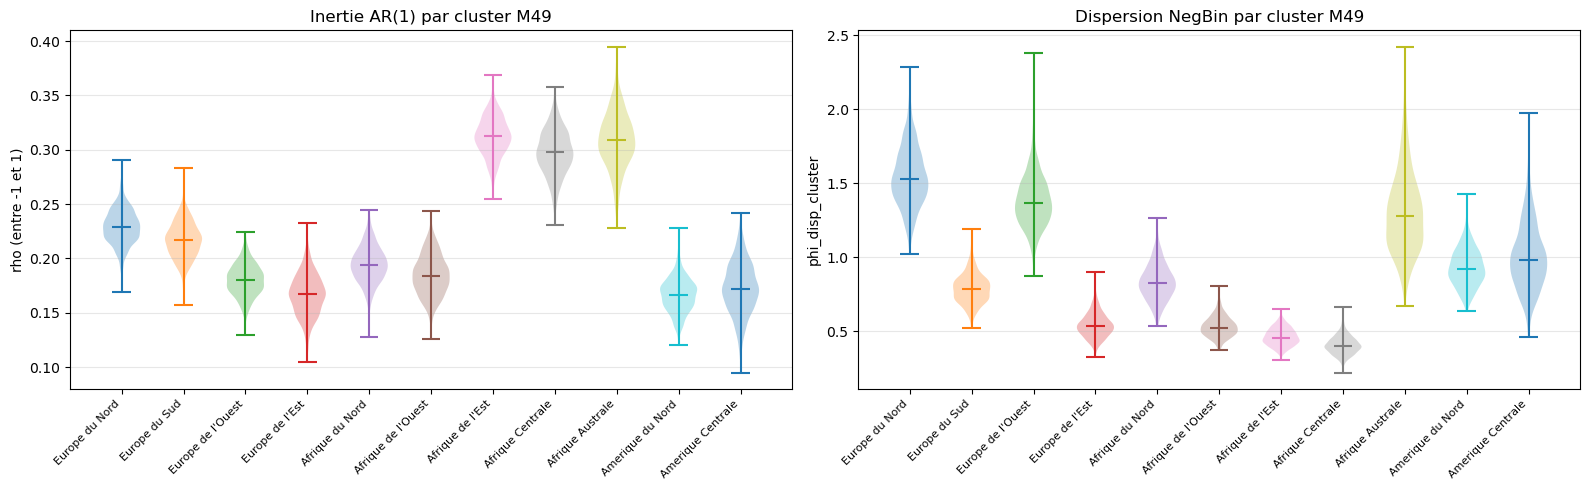

In [135]:
# Tableau des coefficients Hurdle et Volume
def print_coef_table(name, means, q05, q95, labels):
    print(f"\n[ {name} ]")
    print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10} {'Sig':>5}")
    print("-" * 65)
    for j in range(len(means)):
        col = labels[j] if j < len(labels) else f'[{j+1}]'
        sig = 'OUI' if (q05[j] > 0 or q95[j] < 0) else 'non'
        print(f"{col:<25} {means[j]:>10.3f} {q05[j]:>10.3f} {q95[j]:>10.3f} {sig:>5}")

print_coef_table(
    'HURDLE (Logit)',
    beta_h.mean(axis=0),
    np.percentile(beta_h, 5, axis=0),
    np.percentile(beta_h, 95, axis=0),
    HURDLE_VARS
)

print_coef_table(
    'VOLUME (ZTNB)',
    beta_grav.mean(axis=0),
    np.percentile(beta_grav, 5, axis=0),
    np.percentile(beta_grav, 95, axis=0),
    X_VOL_COLS
)
rho_m49_draws       = df_final.filter(like='rho_m49').values
phi_cluster_draws   = df_final.filter(like='phi_disp_cluster').values
cluster_labels      = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                       for k in range(1, K_clusters + 1)]

print_coef_table(
    'RHO AR(1) par cluster M49',
    rho_m49_draws.mean(axis=0),
    np.percentile(rho_m49_draws,  5, axis=0),
    np.percentile(rho_m49_draws, 95, axis=0),
    cluster_labels
)

print_coef_table(
    'PHI dispersion par cluster M49',
    phi_cluster_draws.mean(axis=0),
    np.percentile(phi_cluster_draws,  5, axis=0),
    np.percentile(phi_cluster_draws, 95, axis=0),
    cluster_labels
)

# Figure comparative rho vs phi par cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, draws, title, ylabel in [
    (axes[0], rho_m49_draws,     'Inertie AR(1) par cluster M49',       'rho (entre -1 et 1)'),
    (axes[1], phi_cluster_draws, 'Dispersion NegBin par cluster M49',   'phi_disp_cluster'),
]:
    for k in range(draws.shape[1]):
        ax.violinplot(draws[:, k], positions=[k + 1], widths=0.6, showmedians=True)
    ax.set_xticks(range(1, K_clusters + 1))
    ax.set_xticklabels(cluster_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"rho_phi_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

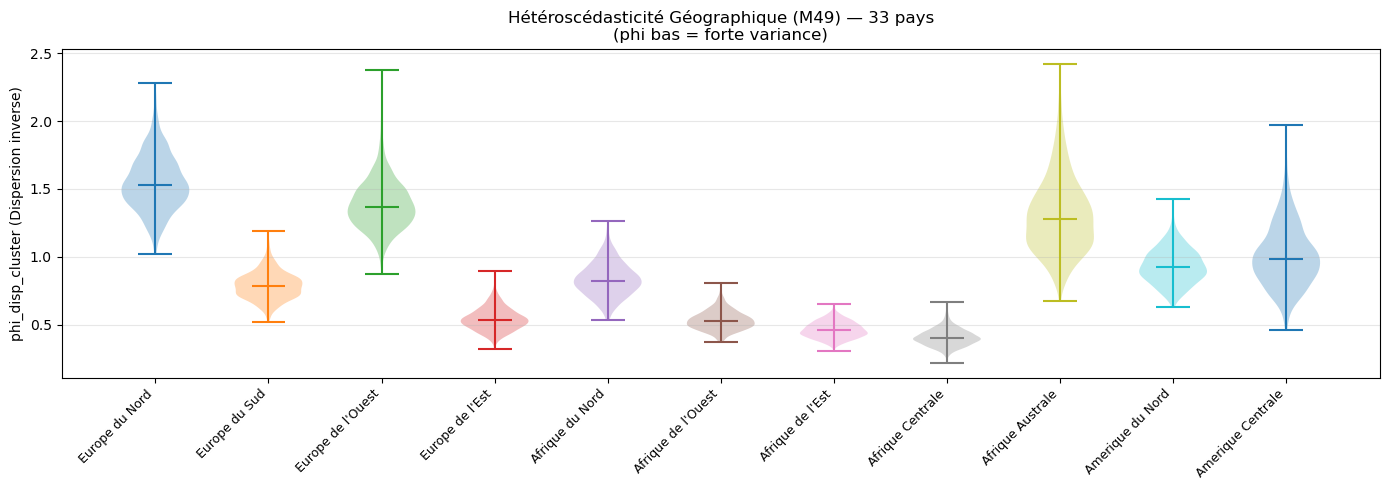

In [136]:
# Figure : hétéroscédasticité M49
fig, ax = plt.subplots(figsize=(14, 5))
for k in range(1, K_clusters + 1):
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels(
    [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'Cluster {k}') for k in range(1, K_clusters + 1)],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("phi_disp_cluster (Dispersion inverse)")
ax.set_title(f"Hétéroscédasticité Géographique (M49) — {N_pays} pays\n(phi bas = forte variance)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"NegBin_dispersion_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

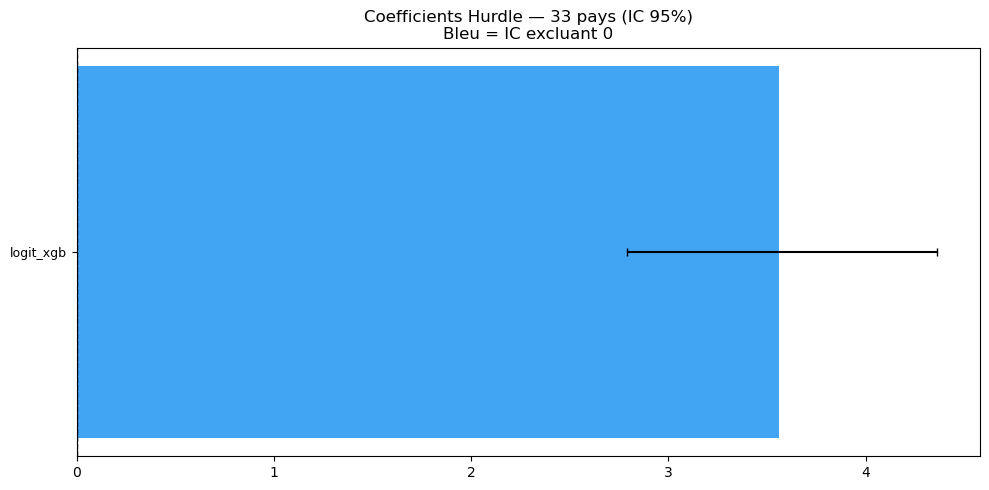

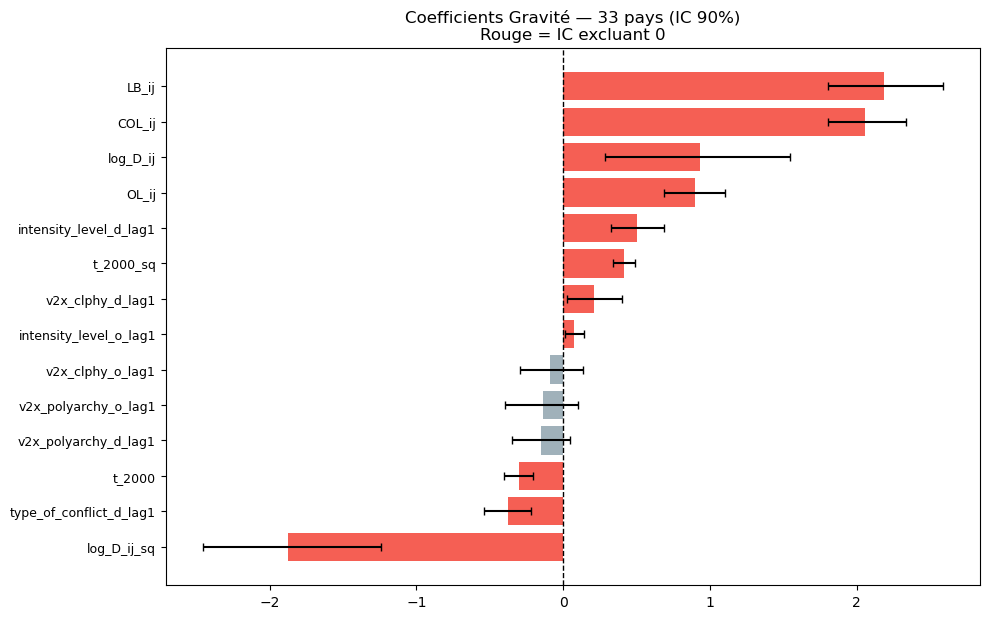

In [137]:
# Figure : coefficients Hurdle et Volume
def plot_coefs(means, q05, q95, labels, title, color_sig, fname):
    K = len(means)
    order = np.argsort(means)
    colors = [color_sig if (q05[i] > 0 or q95[i] < 0) else '#90A4AE' for i in order]
    fig, ax = plt.subplots(figsize=(10, max(5, K * 0.45)))
    ax.barh(
        range(K), means[order],
        xerr=[means[order] - q05[order], q95[order] - means[order]],
        color=colors, alpha=0.85, capsize=3
    )
    ax.set_yticks(range(K))
    ax.set_yticklabels([labels[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

plot_coefs(
    beta_h.mean(axis=0), np.percentile(beta_h, 2.5, axis=0), np.percentile(beta_h, 97.5, axis=0),
    HURDLE_VARS,
    f"Coefficients Hurdle — {N_pays} pays (IC 95%)\nBleu = IC excluant 0",
    '#2196F3', f"NegBin_hurdle_coefficients_{N_pays}.pdf"
)

plot_coefs(
    beta_grav.mean(axis=0), np.percentile(beta_grav, 2.5, axis=0), np.percentile(beta_grav, 97.5, axis=0),
    X_VOL_COLS,
    f"Coefficients Gravité — {N_pays} pays (IC 90%)\nRouge = IC excluant 0",
    '#F44336', f"NegBin_gravity_coefficients_{N_pays}.pdf"
)

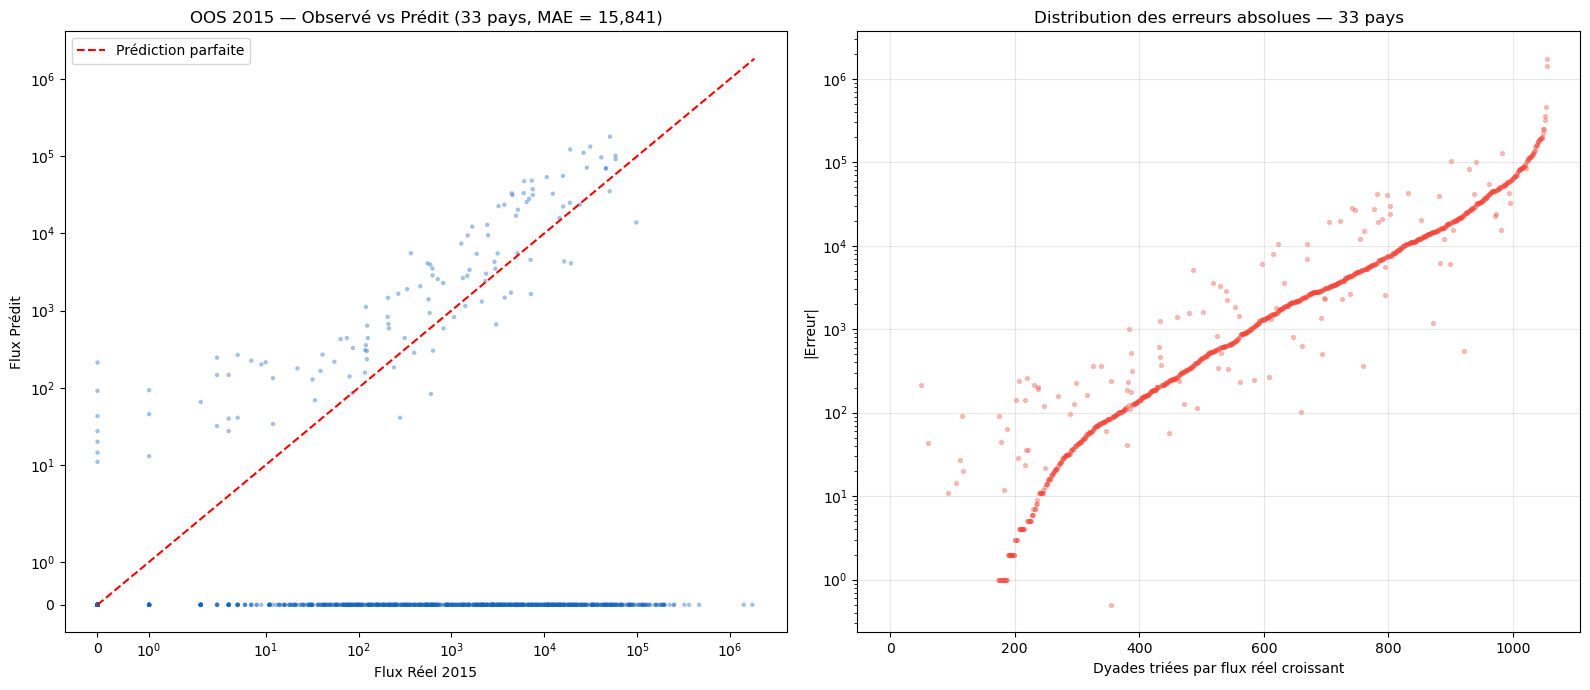

In [138]:
# Figure : scatter OOS + distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit ({N_pays} pays, MAE = {global_mae:,.0f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title(f"Distribution des erreurs absolues — {N_pays} pays")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"NegBin_prediction_scatter_{N_pays}.pdf", bbox_inches='tight')
plt.show()

In [139]:
# Cartographie FP / FN
import plotly.express as px

df_test['y_true_bin'] = y_true_bin
df_test['y_pred_bin'] = y_pred_bin
df_test['FN'] = ((df_test['y_true_bin'] == 1) & (df_test['y_pred_bin'] == 0)).astype(int)
df_test['FP'] = ((df_test['y_true_bin'] == 0) & (df_test['y_pred_bin'] == 1)).astype(int)

error_map = df_test.groupby('orig')[['FN', 'FP']].sum().reset_index()
print(f"FN : {df_test['FN'].sum()} | FP : {df_test['FP'].sum()}")

for col, scale, title in [
    ('FN', 'Reds',  'Cartographie Faux Négatifs (FN) par pays d\'origine'),
    ('FP', 'Blues', 'Cartographie Faux Positifs (FP) par pays d\'origine'),
]:
    fig = px.choropleth(
        error_map, locations='orig', color=col,
        hover_name='orig', color_continuous_scale=scale,
        title=title, labels={col: f'Nombre de {col}'}
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
    fig.show()

FN : 767 | FP : 7
